In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Breast Cancer Wisconsin dataset
data = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

# Add target
df["Outcome"] = data.target

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (569, 31)


In [3]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nDataset Information:")
df.info()

Number of rows: 569
Number of columns: 31

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error      

In [5]:
print("Summary Statistics:")
display(df.describe())

print("Mean:")
display(df.mean(numeric_only=True))

print("Median:")
display(df.median(numeric_only=True))

print("Standard Deviation:")
display(df.std(numeric_only=True))

Summary Statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Mean:


,0
mean radius,14.127292
mean texture,19.289649
mean perimeter,91.969033
mean area,654.889104
mean smoothness,0.096360
mean compactness,0.104341
mean concavity,0.088799
mean concave points,0.048919
mean symmetry,0.181162
mean fractal dimension,0.062798


Median:


,0
mean radius,13.370000
mean texture,18.840000
mean perimeter,86.240000
mean area,551.100000
mean smoothness,0.095870
mean compactness,0.092630
mean concavity,0.061540
mean concave points,0.033500
mean symmetry,0.179200
mean fractal dimension,0.061540


Standard Deviation:


,0
mean radius,3.524049
mean texture,4.301036
mean perimeter,24.298981
mean area,351.914129
mean smoothness,0.014064
mean compactness,0.052813
mean concavity,0.079720
mean concave points,0.038803
mean symmetry,0.027414
mean fractal dimension,0.007060


In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Outcome                    0
dtype: int64

Total missing values: 0


In [7]:
# Handle missing numerical values using median
df.fillna(df.median(numeric_only=True), inplace=True)

print("Missing values after handling:",
      df.isnull().sum().sum())

Missing values after handling: 0


In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [9]:
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (569, 31)


In [10]:
print("Class Distribution:")
print(df["Outcome"].value_counts())

print("\nClass Distribution (%):")
print(df["Outcome"].value_counts(normalize=True) * 100)

Class Distribution:
Outcome
1    357
0    212
Name: count, dtype: int64

Class Distribution (%):
Outcome
1    62.741652
0    37.258348
Name: proportion, dtype: float64


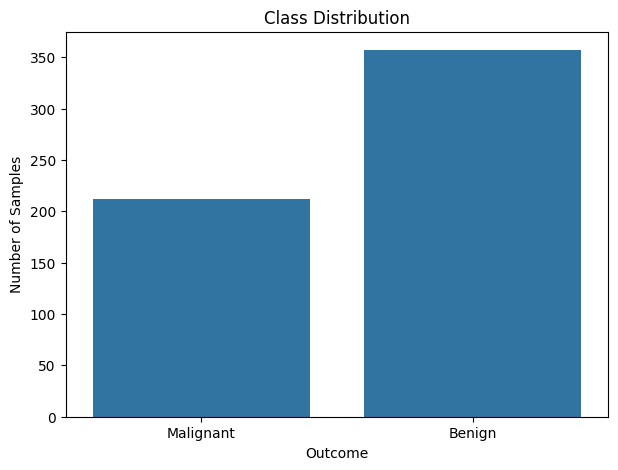

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="Outcome",
    data=df
)

plt.title("Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Samples")
plt.xticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.show()

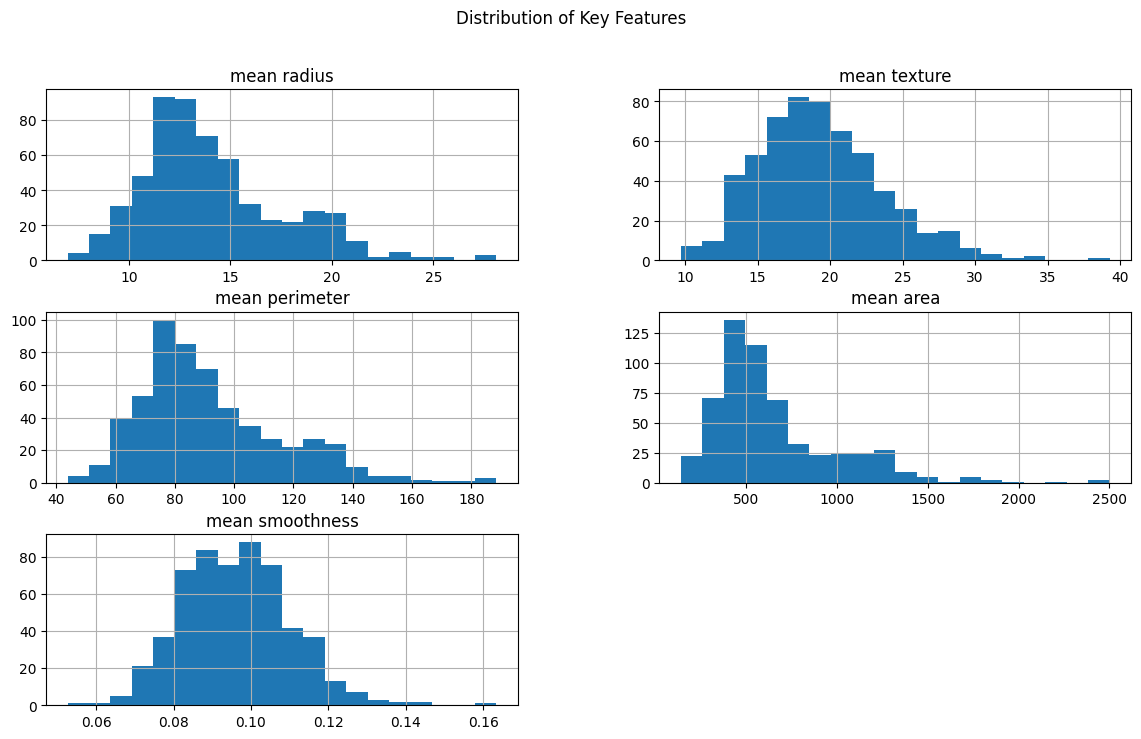

In [12]:
key_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

df[key_features].hist(
    figsize=(14, 8),
    bins=20
)

plt.suptitle("Distribution of Key Features")
plt.show()

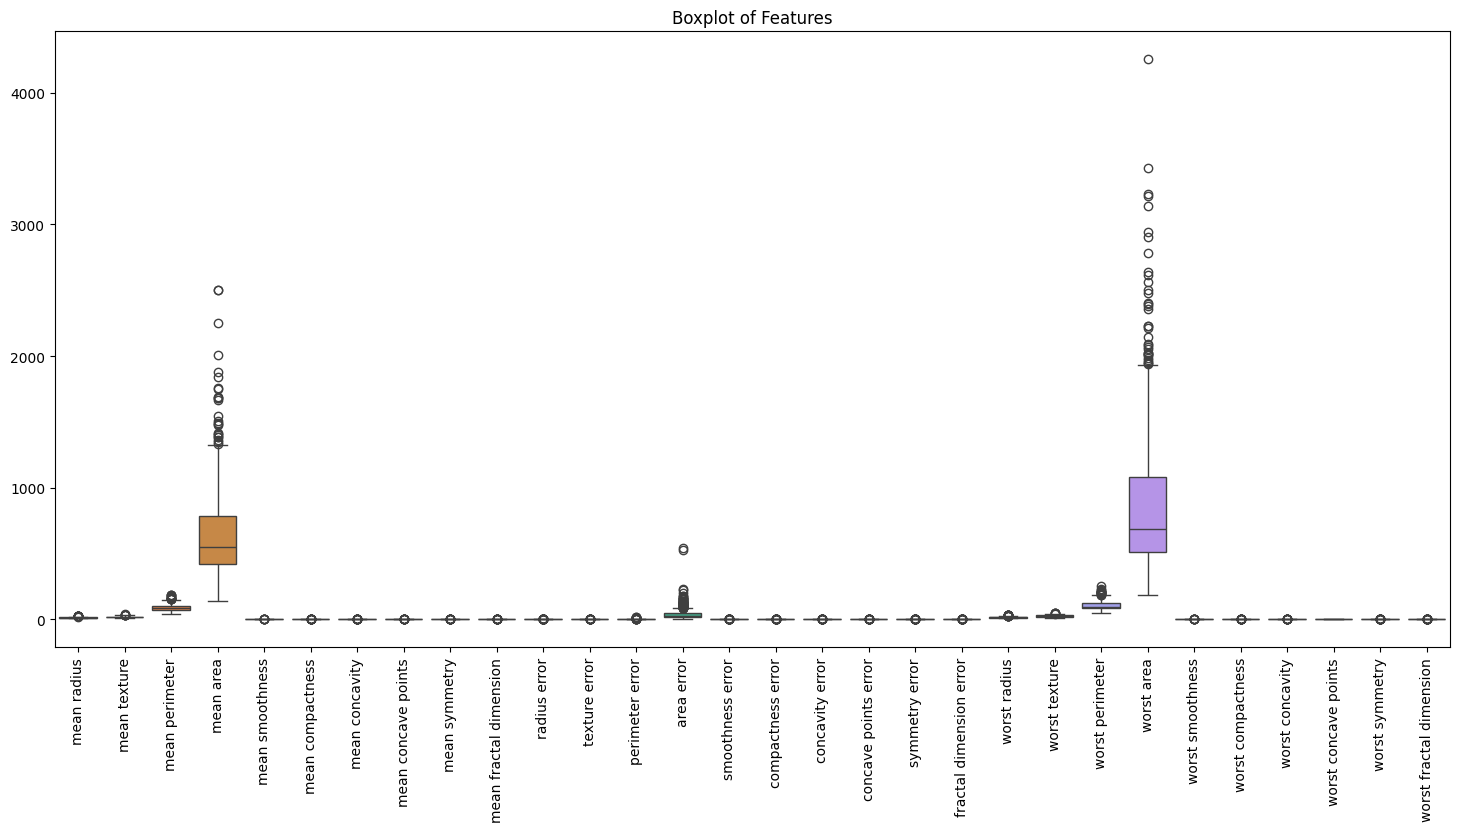

In [13]:
plt.figure(figsize=(18, 8))

sns.boxplot(
    data=df.drop(columns=["Outcome"])
)

plt.title("Boxplot of Features")
plt.xticks(rotation=90)

plt.show()

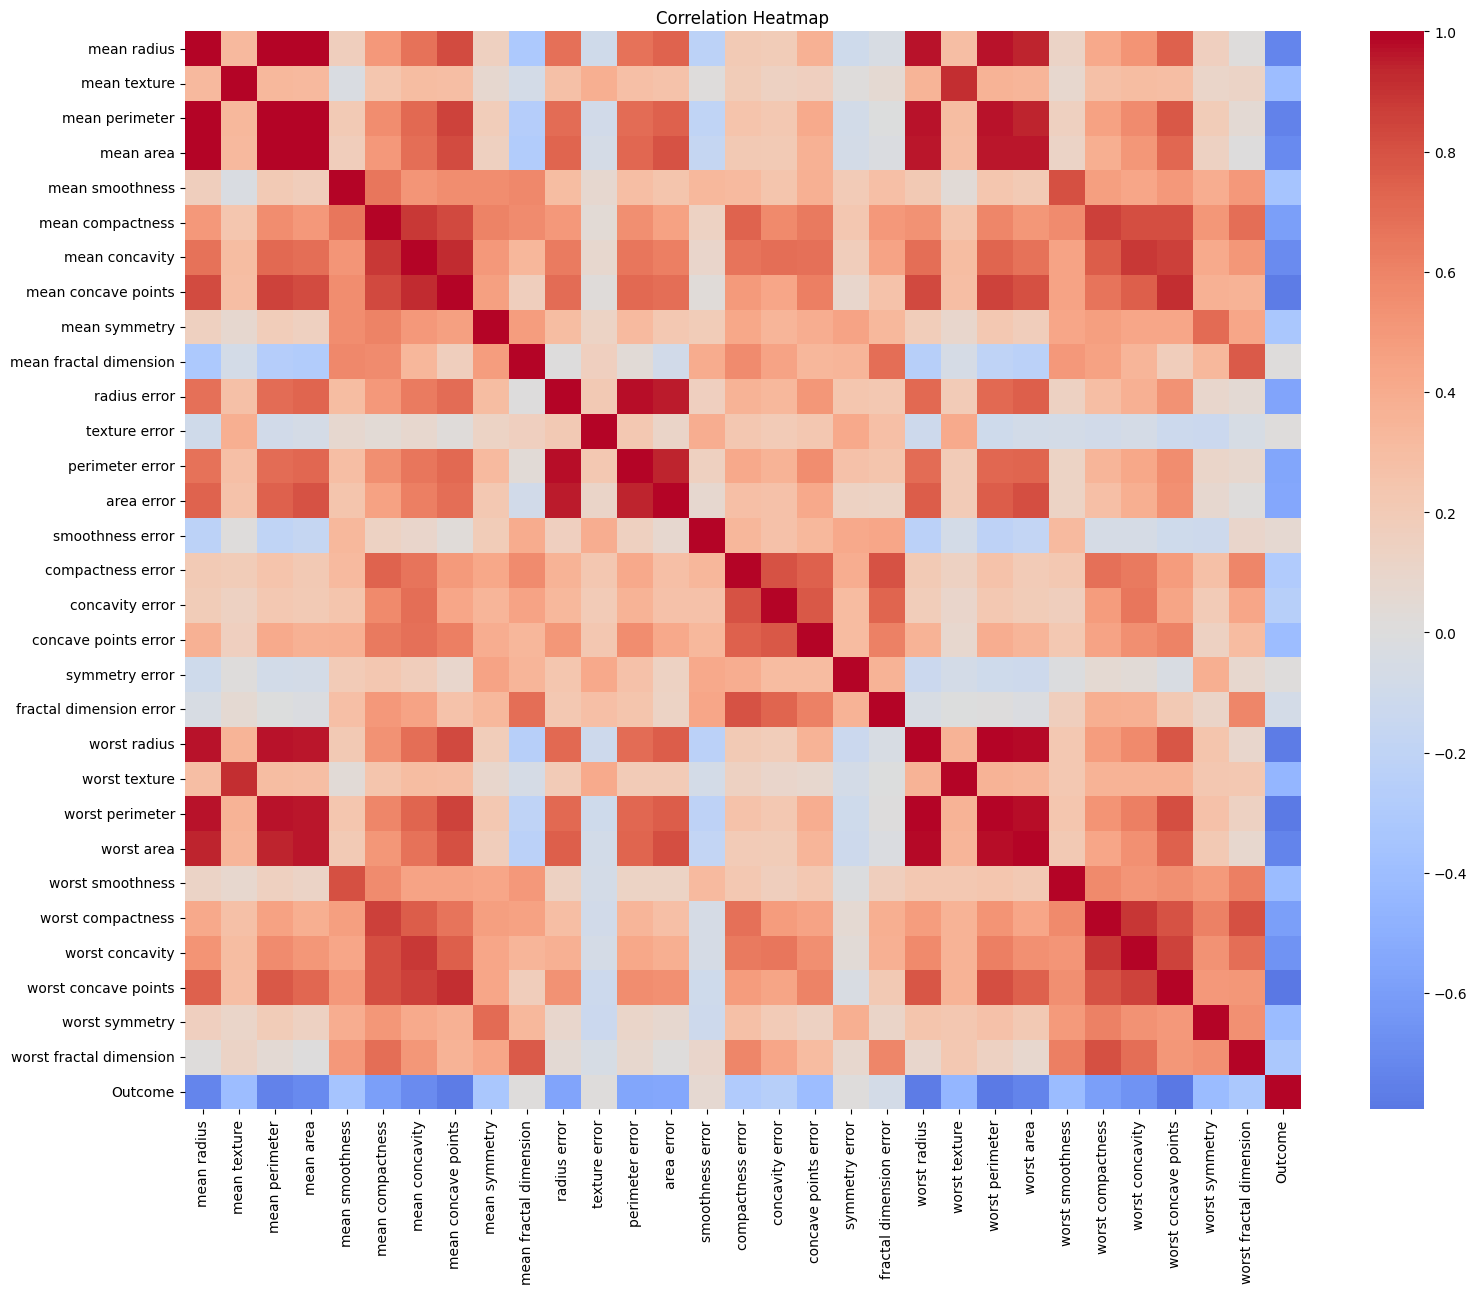

In [14]:
plt.figure(figsize=(18, 14))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [15]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (569, 30)
Target shape: (569,)


In [16]:
# Part A

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("80/20 SPLIT")
print("-" * 30)

print("Training samples:", X_train_80.shape[0])
print("Testing samples:", X_test_80.shape[0])

print("\nTraining class distribution:")
print(y_train_80.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test_80.value_counts(normalize=True))

80/20 SPLIT
------------------------------
Training samples: 455
Testing samples: 114

Training class distribution:
Outcome
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Testing class distribution:
Outcome
1    0.631579
0    0.368421
Name: proportion, dtype: float64


In [17]:
scaler_80 = StandardScaler()

X_train_80_scaled = scaler_80.fit_transform(X_train_80)

X_test_80_scaled = scaler_80.transform(X_test_80)

print("80/20 data standardized successfully!")

80/20 data standardized successfully!


In [18]:
model_80 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_80.fit(
    X_train_80_scaled,
    y_train_80
)

print("80/20 Logistic Regression model trained!")

80/20 Logistic Regression model trained!


In [19]:
y_pred_80 = model_80.predict(X_test_80_scaled)

# Probability for class 1
y_prob_80 = model_80.predict_proba(X_test_80_scaled)[:, 1]

print("Predictions generated!")

Predictions generated!


In [20]:
accuracy_80 = accuracy_score(y_test_80, y_pred_80)

precision_80 = precision_score(
    y_test_80,
    y_pred_80,
    average="weighted"
)

recall_80 = recall_score(
    y_test_80,
    y_pred_80,
    average="weighted"
)

f1_80 = f1_score(
    y_test_80,
    y_pred_80,
    average="weighted"
)

auc_80 = roc_auc_score(
    y_test_80,
    y_prob_80
)

print("80/20 MODEL PERFORMANCE")
print("=" * 40)

print(f"Accuracy  : {accuracy_80:.4f}")
print(f"Precision : {precision_80:.4f}")
print(f"Recall    : {recall_80:.4f}")
print(f"F1 Score  : {f1_80:.4f}")
print(f"AUC       : {auc_80:.4f}")

80/20 MODEL PERFORMANCE
Accuracy  : 0.9825
Precision : 0.9825
Recall    : 0.9825
F1 Score  : 0.9825
AUC       : 0.9954


In [21]:
print(
    classification_report(
        y_test_80,
        y_pred_80,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [22]:
# Part B

test_size=0.30

In [23]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("70/30 SPLIT")
print("-" * 30)

print("Training samples:", X_train_70.shape[0])
print("Testing samples:", X_test_70.shape[0])

print("\nTraining class distribution:")
print(y_train_70.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test_70.value_counts(normalize=True))

70/30 SPLIT
------------------------------
Training samples: 398
Testing samples: 171

Training class distribution:
Outcome
1    0.628141
0    0.371859
Name: proportion, dtype: float64

Testing class distribution:
Outcome
1    0.625731
0    0.374269
Name: proportion, dtype: float64


In [24]:
scaler_70 = StandardScaler()

X_train_70_scaled = scaler_70.fit_transform(X_train_70)

X_test_70_scaled = scaler_70.transform(X_test_70)

print("70/30 data standardized successfully!")

70/30 data standardized successfully!


In [25]:
model_70 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_70.fit(
    X_train_70_scaled,
    y_train_70
)

print("70/30 Logistic Regression model trained!")

70/30 Logistic Regression model trained!


In [26]:
y_pred_70 = model_70.predict(X_test_70_scaled)

y_prob_70 = model_70.predict_proba(
    X_test_70_scaled
)[:, 1]

print("70/30 predictions generated!")

70/30 predictions generated!


In [27]:
accuracy_70 = accuracy_score(y_test_70, y_pred_70)

precision_70 = precision_score(
    y_test_70,
    y_pred_70,
    average="weighted"
)

recall_70 = recall_score(
    y_test_70,
    y_pred_70,
    average="weighted"
)

f1_70 = f1_score(
    y_test_70,
    y_pred_70,
    average="weighted"
)

auc_70 = roc_auc_score(
    y_test_70,
    y_prob_70
)

print("70/30 MODEL PERFORMANCE")
print("=" * 40)

print(f"Accuracy  : {accuracy_70:.4f}")
print(f"Precision : {precision_70:.4f}")
print(f"Recall    : {recall_70:.4f}")
print(f"F1 Score  : {f1_70:.4f}")
print(f"AUC       : {auc_70:.4f}")

70/30 MODEL PERFORMANCE
Accuracy  : 0.9883
Precision : 0.9883
Recall    : 0.9883
F1 Score  : 0.9883
AUC       : 0.9981


In [28]:
print(
    classification_report(
        y_test_70,
        y_pred_70,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        64
      Benign       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



In [29]:
# Part C :- Comparison

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "80/20 Split": [
        accuracy_80,
        precision_80,
        recall_80,
        f1_80,
        auc_80
    ],
    "70/30 Split": [
        accuracy_70,
        precision_70,
        recall_70,
        f1_70,
        auc_70
    ]
})

comparison

,Metric,80/20 Split,70/30 Split
0,Accuracy,0.982456,0.988304
1,Precision,0.982456,0.988304
2,Recall,0.982456,0.988304
3,F1 Score,0.982456,0.988304
4,ROC-AUC,0.995370,0.998102


In [30]:
comparison["Difference (70/30 - 80/20)"] = (
    comparison["70/30 Split"] -
    comparison["80/20 Split"]
)

comparison

,Metric,80/20 Split,70/30 Split,Difference (70/30 - 80/20)
0,Accuracy,0.982456,0.988304,0.005848
1,Precision,0.982456,0.988304,0.005848
2,Recall,0.982456,0.988304,0.005848
3,F1 Score,0.982456,0.988304,0.005848
4,ROC-AUC,0.995370,0.998102,0.002731


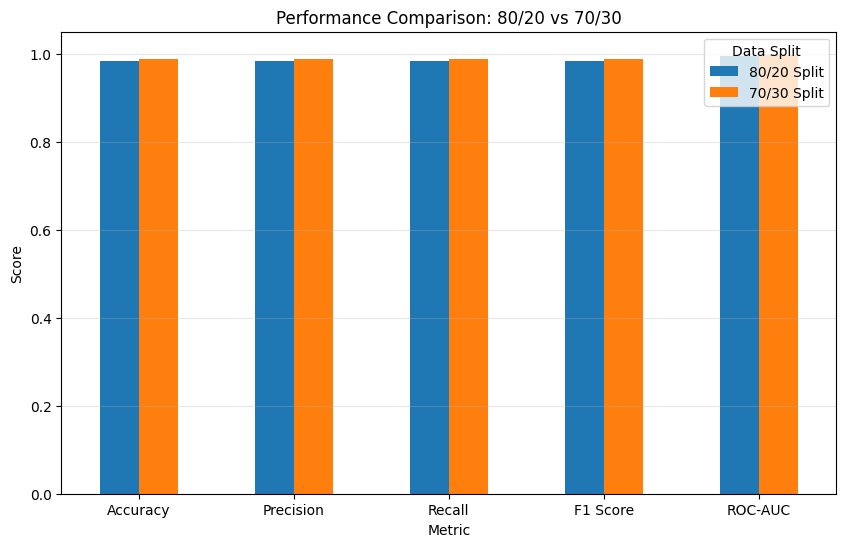

In [31]:
comparison_plot = comparison.set_index("Metric")[
    ["80/20 Split", "70/30 Split"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison: 80/20 vs 70/30")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.legend(title="Data Split")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [32]:
from mpl_toolkits.mplot3d import Axes3D

cm_80 = confusion_matrix(
    y_test_80,
    y_pred_80
)

print("80/20 Confusion Matrix:")
print(cm_80)

80/20 Confusion Matrix:
[[41  1]
 [ 1 71]]


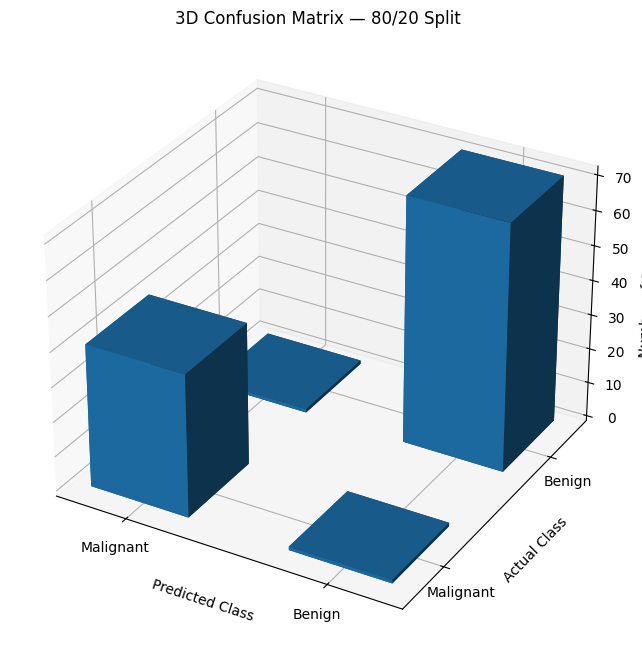

In [33]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

# Coordinates
x_pos = np.array([0, 1, 0, 1])
y_pos = np.array([0, 0, 1, 1])

# Heights
z_pos = np.zeros(4)

dx = np.ones(4) * 0.5
dy = np.ones(4) * 0.5

dz = np.array([
    cm_80[0, 0],
    cm_80[0, 1],
    cm_80[1, 0],
    cm_80[1, 1]
])

# Create bars
ax.bar3d(
    x_pos,
    y_pos,
    z_pos,
    dx,
    dy,
    dz,
    shade=True
)

# Labels
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
ax.set_zlabel("Number of Samples")

ax.set_title("3D Confusion Matrix — 80/20 Split")

ax.set_xticks([0.25, 1.25])
ax.set_xticklabels(["Malignant", "Benign"])

ax.set_yticks([0.25, 1.25])
ax.set_yticklabels(["Malignant", "Benign"])

plt.show()

In [34]:
cm_70 = confusion_matrix(
    y_test_70,
    y_pred_70
)

print("70/30 Confusion Matrix:")
print(cm_70)

70/30 Confusion Matrix:
[[ 63   1]
 [  1 106]]


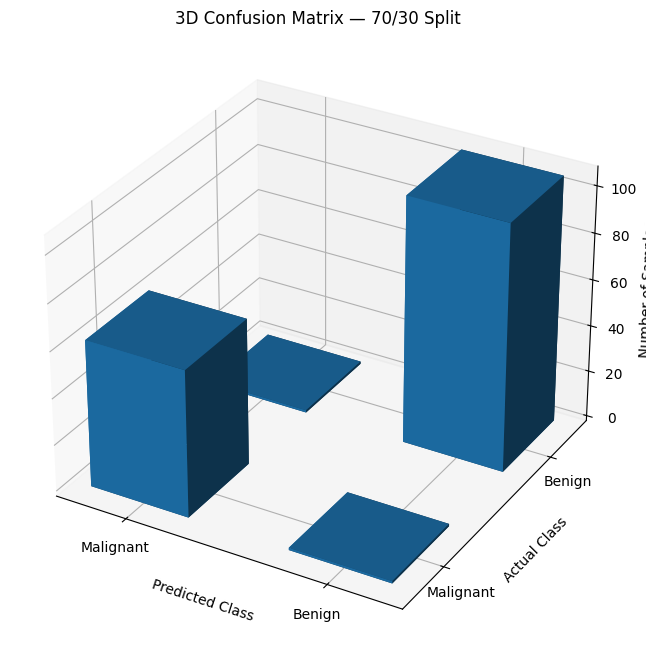

In [35]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

x_pos = np.array([0, 1, 0, 1])
y_pos = np.array([0, 0, 1, 1])

z_pos = np.zeros(4)

dx = np.ones(4) * 0.5
dy = np.ones(4) * 0.5

dz = np.array([
    cm_70[0, 0],
    cm_70[0, 1],
    cm_70[1, 0],
    cm_70[1, 1]
])

ax.bar3d(
    x_pos,
    y_pos,
    z_pos,
    dx,
    dy,
    dz,
    shade=True
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
ax.set_zlabel("Number of Samples")

ax.set_title("3D Confusion Matrix — 70/30 Split")

ax.set_xticks([0.25, 1.25])
ax.set_xticklabels(["Malignant", "Benign"])

ax.set_yticks([0.25, 1.25])
ax.set_yticklabels(["Malignant", "Benign"])

plt.show()

In [36]:
def plot_3d_confusion_matrix(cm, title):

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Positions
    x_pos = np.array([0, 1, 0, 1])
    y_pos = np.array([0, 0, 1, 1])

    z_pos = np.zeros(4)

    dx = np.ones(4) * 0.5
    dy = np.ones(4) * 0.5

    # Matrix values
    dz = np.array([
        cm[0, 0],
        cm[0, 1],
        cm[1, 0],
        cm[1, 1]
    ])

    # Create bars
    ax.bar3d(
        x_pos,
        y_pos,
        z_pos,
        dx,
        dy,
        dz,
        shade=True
    )

    # Add values above bars
    for x, y, z in zip(x_pos, y_pos, dz):

        ax.text(
            x + 0.25,
            y + 0.25,
            z + 2,
            str(int(z)),
            ha="center",
            va="bottom",
            fontsize=12
        )

    # Labels
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")
    ax.set_zlabel("Number of Samples")

    ax.set_title(title)

    ax.set_xticks([0.25, 1.25])
    ax.set_xticklabels([
        "Malignant",
        "Benign"
    ])

    ax.set_yticks([0.25, 1.25])
    ax.set_yticklabels([
        "Malignant",
        "Benign"
    ])

    plt.show()

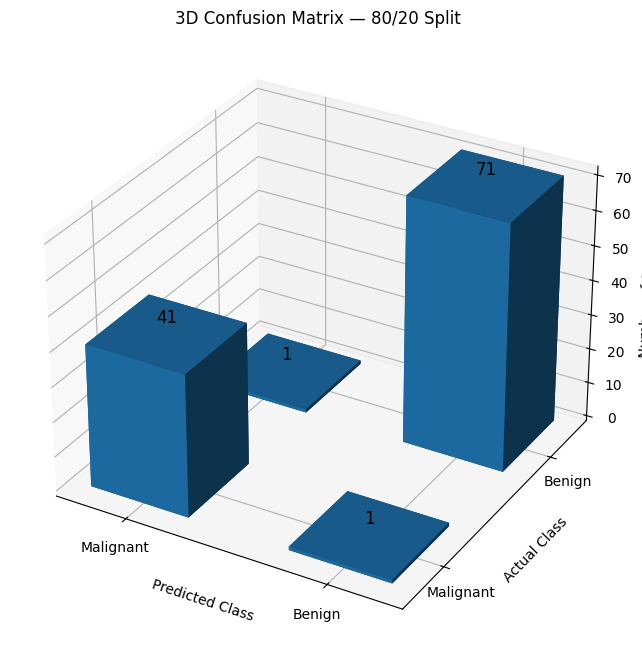

In [37]:
plot_3d_confusion_matrix(
    cm_80,
    "3D Confusion Matrix — 80/20 Split"
)

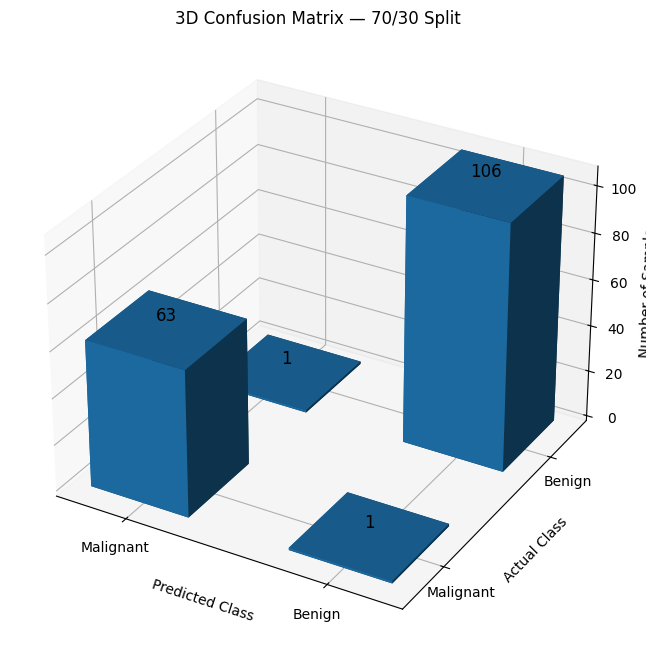

In [38]:
plot_3d_confusion_matrix(
    cm_70,
    "3D Confusion Matrix — 70/30 Split"
)

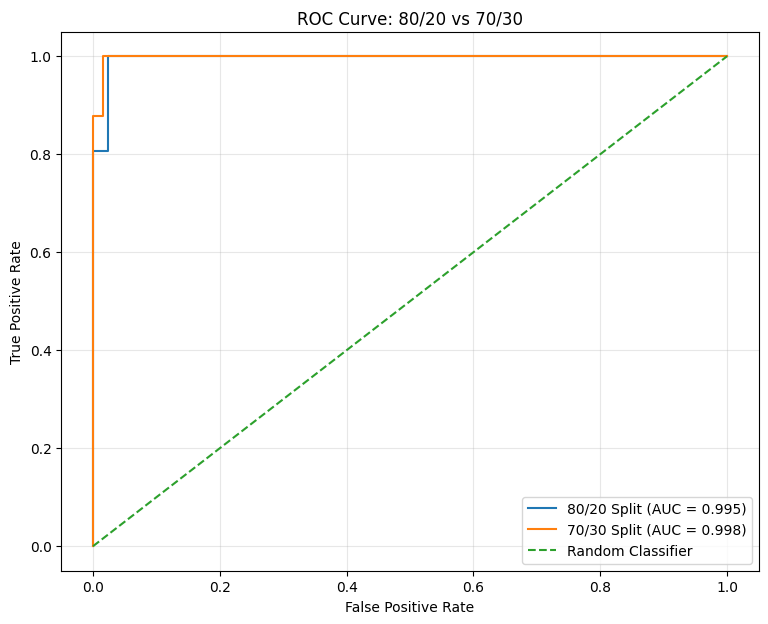

In [39]:
# ROC for 80/20
fpr_80, tpr_80, _ = roc_curve(
    y_test_80,
    y_prob_80
)

# ROC for 70/30
fpr_70, tpr_70, _ = roc_curve(
    y_test_70,
    y_prob_70
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_80,
    tpr_80,
    label=f"80/20 Split (AUC = {auc_80:.3f})"
)

plt.plot(
    fpr_70,
    tpr_70,
    label=f"70/30 Split (AUC = {auc_70:.3f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve: 80/20 vs 70/30")

plt.legend()

plt.grid(alpha=0.3)

plt.show()